# Alpha & Beta parameter analysis

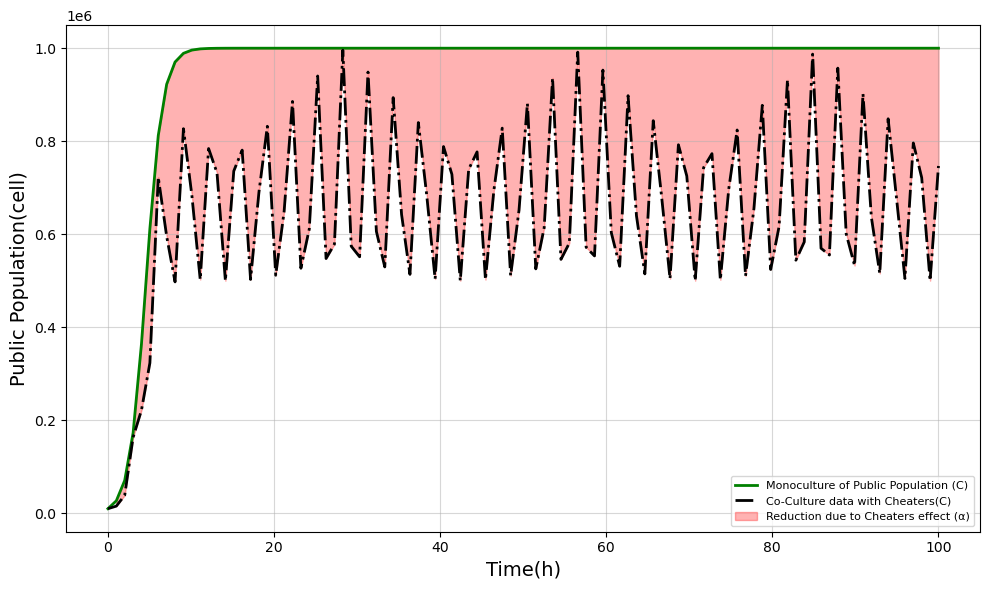

In [2]:
# Importing required libraries
import matplotlib.pyplot as plt
import numpy as np

# Define the simulation function
def simulate_tripartite_model():
    # Time range for simulation
    time = np.linspace(0, 100, 100)

    # Parameters for population dynamics
    r_c = 1.0  # Intrinsic growth rate of public (C)
    lambda_c = 0.1  # Self-limiting term for cooperators (public)

    # Monoculture population dynamics for public (C)
    C_mono_pop = 1 / (1 + (1 / 0.01 - 1) * np.exp(-r_c * time))
    cell_number_mono = C_mono_pop * 1e6  # Convert to cell number

    # Case 1: No exploitation (alpha = 0)
    alpha_zero = 0.0
    D_effect_zero = -alpha_zero * np.abs(np.sin(time))
    C_co_D_zero_pop = C_mono_pop * (1 + D_effect_zero)
    cell_number_co_D_zero = C_co_D_zero_pop * 1e6

    # Case 2: Moderate exploitation (alpha = 0.5)
    alpha_value = 0.5
    D_effect_value = -alpha_value * np.abs(np.sin(time))
    C_co_D_value_pop = C_mono_pop * (1 + D_effect_value)
    cell_number_co_D_value = C_co_D_value_pop * 1e6

    # Plotting Public (C) and Cheaters (D)
    plt.figure(figsize=(10, 6))

    # Monoculture of public
    plt.plot(time, cell_number_mono, label='Monoculture of Public Population (C)', color='green', linewidth=2)

    # Co-culture with cheaters when alpha = 0
   # plt.plot(time, cell_number_co_D_zero, label='Co-Culture with Cheaters (α=0)', color='red', linestyle='--', linewidth=2)

    # Co-culture with cheaters when alpha = 0.5
    plt.plot(time, cell_number_co_D_value, label='Co-Culture data with Cheaters(C)', color='black', linestyle='-.', linewidth=2)

    # Highlighting the reduction area
    plt.fill_between(time, cell_number_co_D_value, cell_number_mono, where=(cell_number_mono > cell_number_co_D_value),
                     color='red', alpha=0.3, label='Reduction due to Cheaters effect (α)')

    # Adding graph details
    #plt.title("Tripartite Model: Public (C) and Cheaters (D)", fontsize=16)
    plt.xlabel("Time(h)", fontsize=14)
    plt.ylabel("Public Population(cell)", fontsize=14)
    plt.legend(fontsize=8, loc="lower right")
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()


# Run the simulation
simulate_tripartite_model()


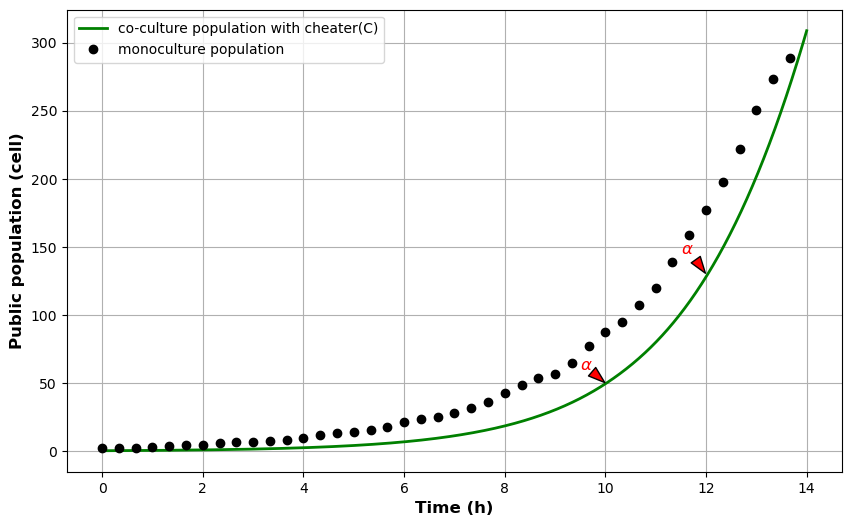

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from src.parameters import parameters
import os
# Define the System of ODEs
def deriv(t, y, params):
    C, D, P = y

    # Population Dynamics Equations
    dC = (params["r_c"] * C 
          - params["alpha"] * C * D  
          - params["eta"] * C**2)

    dD = (params["alpha"] * C * D 
          - params["nu"] * D**2)

    dP = (params["r_p"] * P 
          - params["beta"] * P * C 
          - params["gamma"] * P**2)

    return [dC, dD, dP]

# Simulation Parameters
T = 14                # Total simulation time
C0, D0, P0 = 1, 1, 1  # Initial populations
initial_conditions = [C0, D0, P0]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv, [0, T], initial_conditions, t_eval=time, args=(parameters,), method="RK45"
)

# Extract Results
C_sol, D_sol, P_sol = solution.y

# Read the experimental data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # First column (time)
last_column_3 = df3.iloc[:, -1]  # Last column (data to plot)

# Find the maximum value in the experimental data
max_value = last_column_3.max()

# Normalize the simulation results by the maximum value of the experimental data
C_sol_normalized = C_sol / C_sol.max() * max_value
D_sol_normalized = D_sol / D_sol.max() * max_value
P_sol_normalized = P_sol / P_sol.max() * max_value

# Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(time, C_sol_normalized, label='co-culture population with cheater(C)',color='g', linestyle='-', linewidth=2 )

# Plot the data from the second file (4018 C. glutamicum + 4056 E. coli)
plt.plot(first_column_3.iloc[:42], last_column_3.iloc[:42], label='monoculture population',color='black', marker="o", linestyle="None")


# Add arrows to indicate the effect of alpha
arrow_params = dict(facecolor="red", shrink=0.05, width=2, headwidth=8)



plt.annotate(r"$\alpha$",
             xy=(10, 50), xytext=(9.5, 60),
             arrowprops=arrow_params, fontsize= 12, color='red')

plt.annotate(r"$\alpha$",
             xy=(12, 130), xytext=(11.5, 145),
             arrowprops=arrow_params, fontsize=12, color='red')





#plt.title('Public metabolizer in mono and co-culture')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Public population (cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/alpha analysis.png", dpi=300)
plt.show()

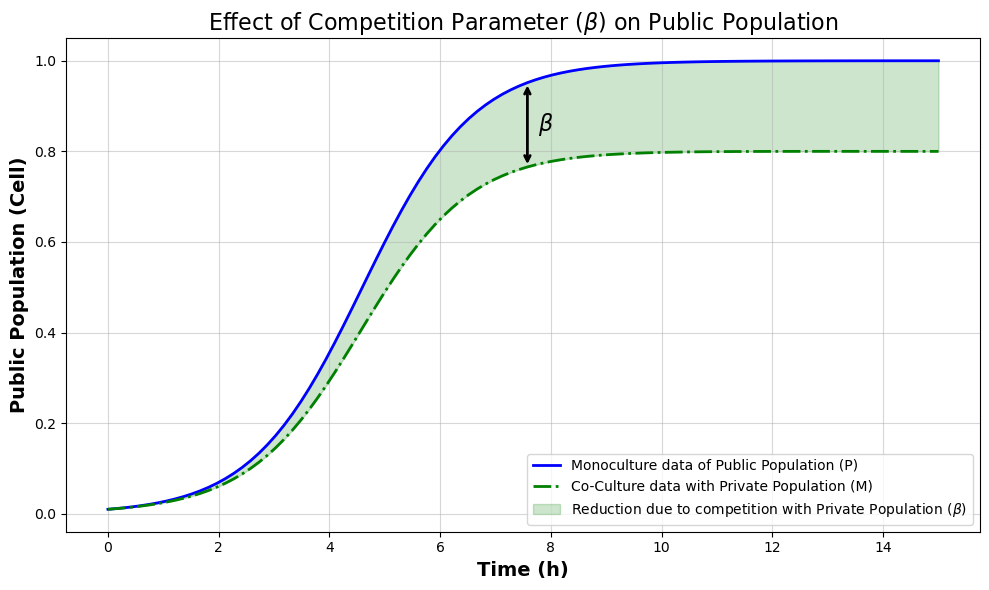

<Figure size 640x480 with 0 Axes>

In [5]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import os
# Time points for simulation
time = np.linspace(0, 15, 100)

# Parameters for population dynamics
r_c = 1.0       # Intrinsic growth rate of public population (C)
lambda_c = 0.1  # Self-limiting term for public population (C)
beta = 0.3      # Competition effect from private population (P)

# Monoculture Dynamics: Public Population (C)
C_mono_pop = 1 / (1 + (1 / 0.01 - 1) * np.exp(-r_c * time))  # Logistic growth model
C_mono_cell_count = C_mono_pop  # Directly representing cell count for clarity

# Co-Culture Dynamics: Public Population (C) with Private Population (P)
P_effect = beta * (1 - np.exp(-0.5 * time))  # Private population effect (arbitrary function)
C_co_P_pop = C_mono_pop * (1 - 0.2 * P_effect / max(P_effect))  # Adjust public population based on competition
C_co_P_cell_count = C_co_P_pop  # Convert to cell count for plotting

# Plot: Effect of Private Population (β) on Public Population
plt.figure(figsize=(10, 6))

# Monoculture Line: Public Population (C)
plt.plot(time, C_mono_cell_count, 
         label='Monoculture data of Public Population (P)', 
         color='blue', linewidth=2)

# Co-Culture Line: Public Population (C) under competition
plt.plot(time, C_co_P_cell_count, 
         label='Co-Culture data with Private Population (M)', 
         color='green', linestyle='-.', linewidth=2)

# Highlight the effect of competition with Private Population (β)
plt.fill_between(time, C_mono_cell_count, C_co_P_cell_count, 
                 color='green', alpha=0.2, 
                 label='Reduction due to competition with Private Population ($\\beta$)')

# Add a double-sided arrow to indicate β
mid_time_idx = 50  # Midpoint index for the arrow
mid_time = time[mid_time_idx]
mid_y_top = C_mono_cell_count[mid_time_idx]
mid_y_bottom = C_co_P_cell_count[mid_time_idx]

plt.annotate("", 
             xy=(mid_time, mid_y_top), xytext=(mid_time, mid_y_bottom),
             arrowprops=dict(arrowstyle="<->", color="black", linewidth=2))

# Add the beta label next to the arrow
plt.text(mid_time + 0.2, (mid_y_top + mid_y_bottom) / 2, r"$\beta$", 
         fontsize=16, fontweight='bold', color="black", ha="left", va="center")

# Graph Labels and Legend
plt.xlabel("Time (h)", fontsize=14, fontweight='bold')
plt.ylabel("Public Population (Cell)", fontsize=14, fontweight='bold')
plt.title("Effect of Competition Parameter ($\\beta$) on Public Population", fontsize=16)
plt.legend(fontsize=10, loc="lower right")
plt.grid(alpha=0.5)

# Layout adjustment and show
plt.tight_layout()
plt.show()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/alpha analysis.png", dpi=300)
plt.show()

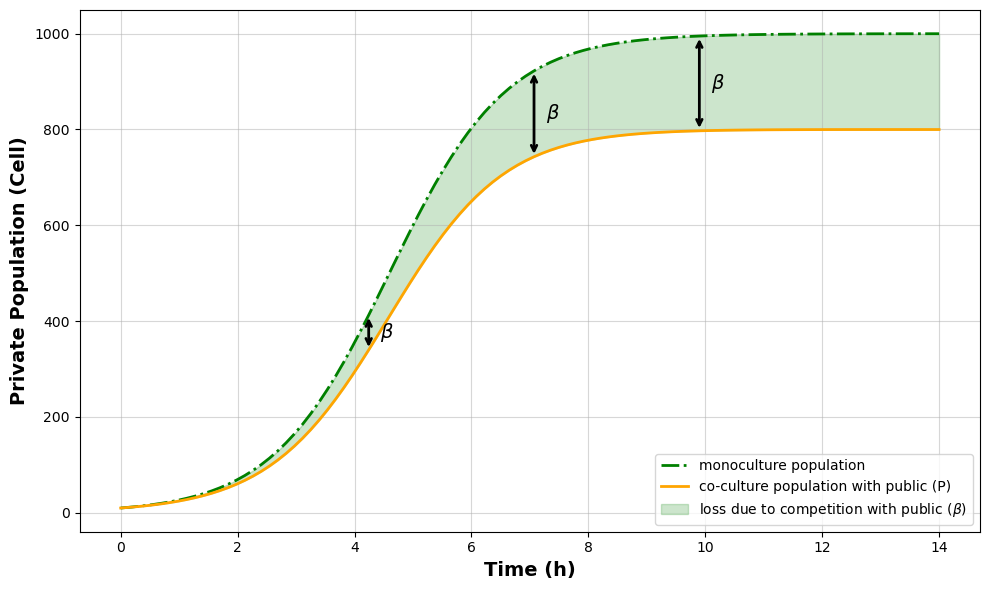

<Figure size 640x480 with 0 Axes>

In [8]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import os
# Time points for simulation
time = np.linspace(0, 14, 100)

# Parameters for population dynamics
r_c = 1.0       # Intrinsic growth rate of public population (C)
lambda_c = 0.1  # Self-limiting term for public population (C)
beta = 0.3      # Competition effect from private population (P)

# Monoculture Dynamics: Public Population (C)
C_mono_pop = 1 / (1 + (1 / 0.01 - 1) * np.exp(-r_c * time))  # Logistic growth model
C_mono_cell_count = C_mono_pop * 1e3  # Directly representing cell count for clarity

# Co-Culture Dynamics: Public Population (C) with Private Population (P)
P_effect = beta * (1 - np.exp(-0.5 * time))  # Private population effect (arbitrary function)
C_co_P_pop = C_mono_pop * (1 - 0.2 * P_effect / max(P_effect))  # Adjust public population based on competition
C_co_P_cell_count = C_co_P_pop * 1e3 # Convert to cell count for plotting

# Plot: Effect of Private Population (β) on Public Population
plt.figure(figsize=(10, 6))

# Monoculture Line: Public Population (C)
plt.plot(time, C_mono_cell_count, 
         label='monoculture population', 
         color='green', linestyle='-.', linewidth=2)

# Co-Culture Line: Public Population (C) under competition
plt.plot(time, C_co_P_cell_count, 
         label='co-culture population with public (P)', 
         color='orange', linewidth=2 )

# Highlight the effect of competition with Private Population (β)
plt.fill_between(time, C_mono_cell_count, C_co_P_cell_count, 
                 color='green', alpha=0.2, 
                 label='loss due to competition with public ($\\beta$)')

# Add three double-sided arrows to indicate β at different locations
arrow_properties = dict(arrowstyle="<->", color="black", linewidth=2)

# Position 1: Early phase
idx1 = 30  # Early time index
plt.annotate("", 
             xy=(time[idx1], C_mono_cell_count[idx1]), 
             xytext=(time[idx1], C_co_P_cell_count[idx1]),
             arrowprops=arrow_properties)
plt.text(time[idx1] + 0.2, (C_mono_cell_count[idx1] + C_co_P_cell_count[idx1]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Position 2: Mid phase
idx2 = 50  # Mid time index
plt.annotate("", 
             xy=(time[idx2], C_mono_cell_count[idx2]), 
             xytext=(time[idx2], C_co_P_cell_count[idx2]),
             arrowprops=arrow_properties)
plt.text(time[idx2] + 0.2, (C_mono_cell_count[idx2] + C_co_P_cell_count[idx2]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Position 3: Late phase
idx3 = 70  # Late time index
plt.annotate("", 
             xy=(time[idx3], C_mono_cell_count[idx3]), 
             xytext=(time[idx3], C_co_P_cell_count[idx3]),
             arrowprops=arrow_properties)
plt.text(time[idx3] + 0.2, (C_mono_cell_count[idx3] + C_co_P_cell_count[idx3]) / 2, 
         r"$\beta$", fontsize=14, fontweight='bold', color="black", ha="left", va="center")

# Graph Labels and Legend
plt.xlabel("Time (h)", fontsize=14, fontweight='bold')
plt.ylabel("Private Population (Cell)", fontsize=14, fontweight='bold')
#plt.title("Effect of Competition Parameter ($\\beta$) on Public Population", fontsize=16)
plt.legend(fontsize=10, loc="lower right")
plt.grid(alpha=0.5)

# Layout adjustment and show
plt.tight_layout()
plt.show()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/beta analysis.png", dpi=300)
plt.show()

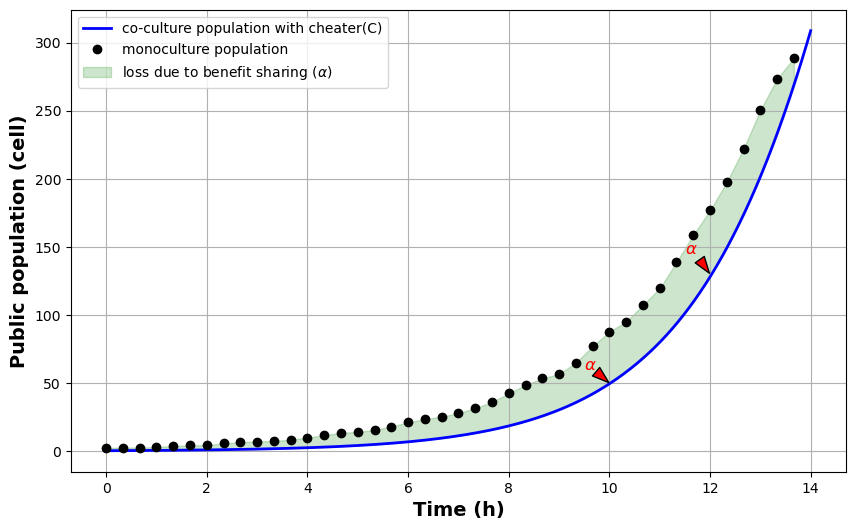

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.integrate import solve_ivp
from src.parameters import parameters

# Define the System of ODEs
def deriv(t, y, params):
    C, D, P = y
    dC = (params["r_c"] * C
          - params["alpha"] * C * D
          - params["eta"] * C**2)
    dD = (params["alpha"] * C * D
          - params["nu"] * D**2)
    dP = (params["r_p"] * P
          - params["beta"] * P * C
          - params["gamma"] * P**2)
    return [dC, dD, dP]

# Simulation Parameters
T = 14                # Total simulation time
C0, D0, P0 = 1, 1, 1  # Initial populations
initial_conditions = [C0, D0, P0]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv,
    [0, T],
    initial_conditions,
    t_eval=time,
    args=(parameters,),
    method="RK45"
)

# Extract Results
C_sol, D_sol, P_sol = solution.y

# Read the experimental data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # Time
last_column_3  = df3.iloc[:, -1] # Data to plot

# Find the maximum value in the experimental data
max_value = last_column_3.max()

# Normalize the simulation results by the maximum value of the experimental data
C_sol_normalized = C_sol / C_sol.max() * max_value
D_sol_normalized = D_sol / D_sol.max() * max_value
P_sol_normalized = P_sol / P_sol.max() * max_value

# Convert the experimental columns to numpy for convenience
x_exp = first_column_3.iloc[:42].to_numpy()
y_exp = last_column_3.iloc[:42].to_numpy()

# --- Interpolate simulation results at the experimental time points ---
#    This aligns them in time so you can fill between the two curves.
y_sim_at_data_points = np.interp(x_exp, time, C_sol_normalized)

# Plot the Results
plt.figure(figsize=(10, 6))

# (1) Plot the simulation (green line)
plt.plot(time, C_sol_normalized,
         label='co-culture population with cheater(C)',
         color='b', linestyle='-', linewidth=2)

# (2) Plot the experimental data (black markers)
plt.plot(x_exp, y_exp,
         label='monoculture population',
         color='black', marker='o', linestyle='None')

# (3) Fill the area between the two curves (green shading)
#     We only fill where we have experimental data (0 to x_exp[-1]).
x_fill = x_exp
y1_fill = y_sim_at_data_points
y2_fill = y_exp

plt.fill_between(x_fill, y1_fill, y2_fill,
                 color='green', alpha=0.2,
                 label='loss due to benefit sharing ($\\alpha$)')

# Add arrows to indicate the effect of alpha
arrow_params = dict(facecolor="red", shrink=0.05, width=2, headwidth=8)
plt.annotate(r"$\alpha$",
             xy=(10, 50), xytext=(9.5, 60),
             arrowprops=arrow_params, fontsize=12, color='red')
plt.annotate(r"$\alpha$",
             xy=(12, 130), xytext=(11.5, 145),
             arrowprops=arrow_params, fontsize=12, color='red')

# Customize plot
plt.xlabel('Time (h)', fontsize=14, fontweight='bold')
plt.ylabel('Public population (cell)', fontsize=14, fontweight='bold')
#plt.title('Comparison of Public Metabolizer in Mono vs. Co-culture', fontsize=14)
plt.legend()
plt.grid(True)

# Save figure
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/alpha_analysis_shaded.png", dpi=300)

# Show the plot
plt.show()


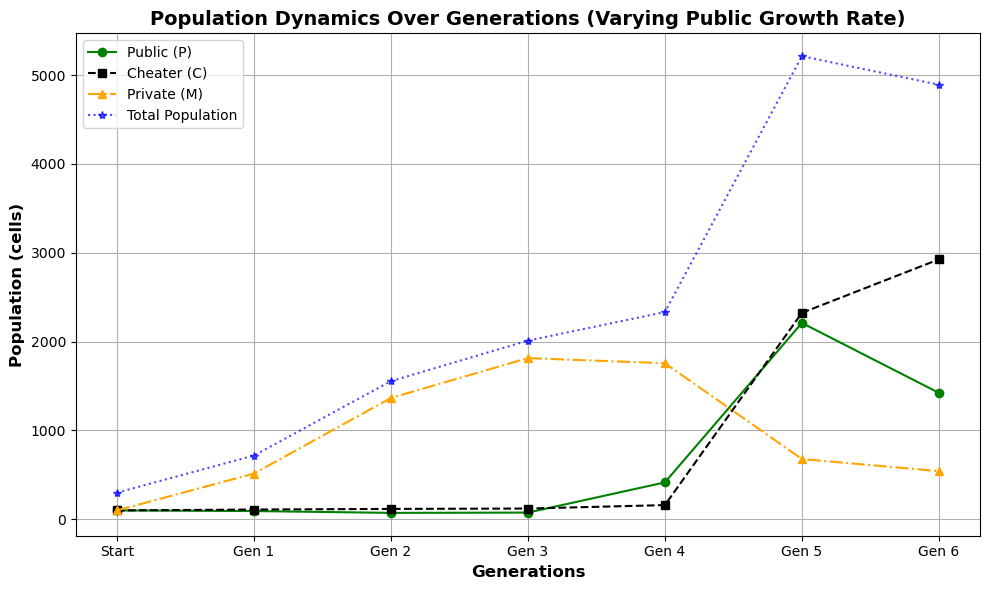

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from src.model import deriv  # Import model function
from src.parameters import parameters  # Import parameters dictionary

# **Time settings**
T = 10  # Total simulation time for each generation
dt = 0.1
time = np.linspace(0, T, int(T/dt))

# **Initial conditions** (before Generation 1 starts)
C_init, D_init, P_init = 100, 100, 100  # Initial population values
generations = ["Start", "Gen 1", "Gen 2", "Gen 3", "Gen 4", "Gen 5", "Gen 6"]

# **Store population values for plotting**
public_pop = [C_init]   # Store initial Public (C) population
cheater_pop = [D_init]  # Store initial Cheater (D) population
private_pop = [P_init]  # Store initial Private (P) population
total_pop = [C_init + D_init + P_init]  # Track total population

# **Define new public growth rates (r_c) for each generation**
public_growth_rates = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8]  # Changing r_c values

# **Run simulation for each generation**
y0 = [C_init, D_init, P_init]  # Initial population
for r_c in public_growth_rates:
    # **Update the public growth rate for this generation**
    parameters["r_c"] = r_c

    # **Run simulation using the replicator dynamics model**
    sol = odeint(deriv, y0, time, args=(
        parameters["nu"],
        parameters["beta"],
        parameters["alpha"],
        parameters["r_c"],  # Updated public growth rate
        parameters["r_p"],
        parameters["gamma"],
        parameters["eta"],
    ))

    # **Extract final population values at the end of the generation**
    final_C, final_D, final_P = sol[-1]

    # **Store values for plotting**
    public_pop.append(final_C)
    cheater_pop.append(final_D)
    private_pop.append(final_P)
    total_pop.append(final_C + final_D + final_P)

    # **Update initial conditions for next generation**
    y0 = [final_C, final_D, final_P]

# **Plot Results**
plt.figure(figsize=(10, 6))

# **Plot each population over generations**
plt.plot(generations, public_pop, marker="o", linestyle="-", color="green", label="Public (P)")
plt.plot(generations, cheater_pop, marker="s", linestyle="--", color="black", label="Cheater (C)")
plt.plot(generations, private_pop, marker="^", linestyle="-.", color="orange", label="Private (M)")

# **Plot total population**
plt.plot(generations, total_pop, marker="*", linestyle=":", color="blue", label="Total Population", alpha=0.7)

# **Formatting**
plt.xlabel("Generations", fontsize=12, fontweight="bold")
plt.ylabel("Population (cells)", fontsize=12, fontweight="bold")
plt.title("Population Dynamics Over Generations (Varying Public Growth Rate)", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# **Save & Show the Figure**
plt.savefig("output/figures/public_growth_variation.png", dpi=300)
plt.show()
